# Format Shortcuts in Brain Tumour MRI Benchmarks: Counterfactual Evaluation and Intervention-Based Debiasing (v5)

## What the data forensics revealed (computed on the Kaggle copy of the dataset, 7200 files)
Every image carries a *file-format signature* (colour mode, JPEG quantisation table, native size). It is almost a label:
- **1248 images in format `RGB | q116 | non-512` are 100% "notumor"** (no tumour image has this format).
- **3023 images in `L | q116 | 512x512` contain 0 "notumor"**.
- Only the format group `RGB | q38` contains all four classes.
So a network can score high by reading *how the file was made* instead of *what the brain looks like*. Earlier K-means "pseudo-sources" were a noisy proxy of this; here the groups are exact, deterministic and explainable.

## Research question
*Do MRI classifiers rely on acquisition-format cues, how much does this cost in real reliability, and can we remove it by intervening on the data-generating process?*

## Contributions
1. **Format-Flip counterfactual test.** Re-render an image in the format of the other class' source (copy the exact JPEG quantisation table and native resolution of a donor image) while keeping the anatomy identical. A model that reads anatomy must not change its prediction. Four controlled variants (**ctrl, compression-only, resolution-only, full flip**) separate the effect of each factor from the effect of simply re-encoding.
2. **Clinical risk metric:** format-induced false negatives (tumour predicted "notumor" after the flip) and false positives.
3. **FormatMix (`do(format)` augmentation).** Re-render training images with a *random donor format drawn independently of the class*. This makes format statistically independent of the label by construction (I(F;Y)=0), which is exactly the condition for counterfactual invariance. **FormatMix + consistency (CCR)** also forces equal predictions across two re-renderings of the same scan.
4. **Why earlier fixes failed (theory):** adversarial invariance enforces F independent of Z marginally, but F and Y are dependent in the data, so it must discard label information; background swap does not touch compression or resolution. Interventions fix the dependence at its source.
5. **Strong baselines:** GroupDRO on forensic groups, product-of-experts debiasing with a format-only bias expert (cross-fitted).
6. **Evaluation:** duplicate-safe 5-fold CV, the **official Training to Testing split**, format-controlled subsets, duplicate-aware bootstrap CIs, paired Wilcoxon tests.

Runtime on a Kaggle T4: about 3 to 4 h (full), about 1 h with `QUICK=1`.

In [1]:
import os, io, glob, re, json, warnings, numpy as np, pandas as pd, matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.nn.functional as F, torchvision
from PIL import Image
from tqdm.auto import tqdm
from scipy.sparse import coo_matrix
from scipy.sparse.csgraph import connected_components
from scipy.stats import wilcoxon
from sklearn.metrics import f1_score, balanced_accuracy_score
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
import imagehash
warnings.filterwarnings("ignore")
E = os.environ.get
DATA_ROOT = E("DATA_ROOT", "/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset")
EXT_ROOT  = E("EXT_ROOT", "")
QUICK = int(E("QUICK", 0))
ARCH1, ARCH2 = E("ARCH1", "convnext_tiny"), ("" if QUICK else E("ARCH2", "resnet50"))
sp_ = lambda s: [int(v) for v in s.split(",") if v != ""]
SEEDS1, SEEDS2 = ([0] if QUICK else sp_(E("SEEDS1", "0,1,2"))), sp_(E("SEEDS2", "0"))
IMG, EPOCHS, BATCH, LR, DRO_ETA = 128, int(E("EPOCHS", 4 if QUICK else 6)), 64, 3e-4, 0.05
K_VAR, DROP_AUG, NFOLD = int(E("K_VAR", 5)), int(E("DROP_AUG", 1)), 5
CCR_LAMBDA, POE_ALPHA, MIN_CELL = 1.0, 1.0, int(E("MIN_CELL", 30))
SUB = int(E("SUB", 0)) or None
OUT = "outputs"; RUNS = f"{OUT}/runs"; MODELS = f"{OUT}/models"
for d in (OUT, RUNS, MODELS): os.makedirs(d, exist_ok=True)
dev = "cuda" if torch.cuda.is_available() else "cpu"
def get_w(name):
    try:
        w = torchvision.models.get_model_weights(name).DEFAULT; torchvision.models.get_model(name, weights=w); return w
    except Exception as e: print("no pretrained weights for", name, "(random init)"); return None
WEIGHTS = {b: get_w(b) for b in filter(None, [ARCH1, ARCH2])}
json.dump(dict(ARCH1=ARCH1, ARCH2=ARCH2, SEEDS1=SEEDS1, SEEDS2=SEEDS2, EPOCHS=EPOCHS, K_VAR=K_VAR, DROP_AUG=DROP_AUG, LR=LR, torch=torch.__version__), open(f"{OUT}/config.json", "w"))
print(dev, ARCH1, ARCH2, SEEDS1, SEEDS2)

Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 210MB/s] 


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 162MB/s] 


cuda convnext_tiny resnet50 [0, 1, 2] [0]


## 1. Data forensics: colour mode, JPEG quantisation table, native size

In [2]:
rows = []
for sp in ["Training", "Testing"]:
    for c in sorted(os.listdir(f"{DATA_ROOT}/{sp}")):
        for f in sorted(glob.glob(f"{DATA_ROOT}/{sp}/{c}/*")):
            with Image.open(f) as im:
                q = getattr(im, "quantization", None) or {}
                rows.append(dict(path=f, orig_split=sp, label=c, w=im.size[0], h=im.size[1], mode=im.mode,
                                 q0=int(sum(q[0][:8])) if 0 in q else -1, qt=tuple(int(v) for v in q[0]) if 0 in q else None))
df = pd.DataFrame(rows)
df["aug"] = df.path.map(lambda p: "aug" in os.path.basename(p).lower())          # pre-augmented copies shipped inside the dataset
print("pre-augmented files:", int(df.aug.sum()), "(dropped)" if DROP_AUG else "(kept)")
if DROP_AUG: df = df[~df.aug]
if SUB: df = df.groupby("label").sample(SUB, random_state=0)
df = df.sort_values("path").reset_index(drop=True); N = len(df)
classes = sorted(df.label.unique()); K = len(classes); NOTU = classes.index("notumor")
y = df.label.map({c: i for i, c in enumerate(classes)}).values.astype(np.int64)
top = [v for v in df.q0.value_counts().index if v > 0][:2]
df["qb"] = df.q0.map(lambda v: f"q{v}" if v in top else "qoth")
msz = df.groupby(["w","h"]).size().idxmax(); df["sz"] = np.where((df.w == msz[0]) & (df.h == msz[1]), "std", "other")
df["md"] = df["mode"].map(lambda m: "L" if m == "L" else "RGB"); df["fg"] = df.md + "|" + df.qb + "|" + df.sz
fgs = sorted(df.fg.unique()); fgid = df.fg.map({g: i for i, g in enumerate(fgs)}).values.astype(np.int64); NFG = len(fgs)
ctab = pd.crosstab(df.fg, df.label); ctab["n"] = ctab.sum(1); print(ctab.sort_values("n", ascending=False).to_string())
big = ctab[ctab.n >= 50]; NSRC = (big["notumor"]/big.n).idxmax()
cand = ctab[(ctab["notumor"]/ctab.n < .05) & (ctab.n >= 200)]; TSRC = cand.n.idxmax()
print(f"\nno-tumour source format: {NSRC} ({int(ctab.loc[NSRC,'notumor'])}/{int(ctab.loc[NSRC,'n'])} are notumor) | tumour source format: {TSRC}")
ctab.to_csv(f"{OUT}/table_format_groups.csv")

pre-augmented files: 203 (dropped)
label           glioma  meningioma  notumor  pituitary     n
fg                                                          
L|q116|std        1399         697        0        915  3011
RGB|q38|std        325         650        8        805  1788
RGB|q116|other       0           0     1248          0  1248
RGB|q38|other       76         245      440         65   826
RGB|qoth|other       0           5       63          0    68
L|q116|other         0           0       24         15    39
RGB|q116|std         0           0       12          0    12
L|qoth|other         0           0        5          0     5

no-tumour source format: RGB|q116|other (1248/1248 are notumor) | tumour source format: L|q116|std


## 2. Format counterfactual engine
`render(image, quantisation_table, size)` re-saves the image as JPEG with a **donor's exact quantisation table and size**, then runs it through the identical preprocessing. Anatomy is unchanged; only the file-format fingerprint changes.
Variants per image: **K training re-renderings** (donor format drawn uniformly from the whole dataset, independent of class) and **4 test counterfactuals** toward the *opposite* class' source format: `ctrl` (own format, only re-encoded), `comp` (compression only), `res` (resolution only), `full`.

In [3]:
S = 256
rs = lambda z, mode: np.asarray(Image.fromarray(z).resize((IMG, IMG), mode))
def std_from(h): return rs(np.asarray(h.convert("L").resize((S, S), Image.BILINEAR)), Image.BILINEAR)
def render(g, qt, size):
    if size != g.size: g = g.resize(size, Image.BILINEAR)
    b = io.BytesIO(); g.save(b, "JPEG", qtables=[list(qt)]); b.seek(0)
    return std_from(Image.open(b))
qts = list(df.qt); ws, hs = df.w.values, df.h.values
valid = np.array([i for i in range(N) if qts[i] is not None])
poolN = np.array([i for i in valid if df.fg[i] == NSRC]); poolT = np.array([i for i in valid if df.fg[i] == TSRC])
CACHE = f"{OUT}/cache_v5_N{N}_K{K_VAR}.npz"
if os.path.exists(CACHE):
    z = np.load(CACHE); Xr, V, Fv, Sm, PH = z["Xr"], z["V"], z["Fv"], z["Sm"], z["PH"]; print("loaded cache")
else:
    rng = np.random.RandomState(0)
    Xr = np.zeros((N,IMG,IMG), np.uint8); V = np.zeros((N,K_VAR,IMG,IMG), np.uint8); Fv = np.zeros((N,4,IMG,IMG), np.uint8)
    Sm = np.zeros((N,32,32), np.float32); PH = np.zeros(N, np.uint64)
    for i in tqdm(range(N)):
        with Image.open(df.path[i]) as im: g0 = im.convert("L")
        own = g0.size; own_qt = qts[i] if qts[i] is not None else qts[rng.choice(valid)]
        g256 = g0.resize((S, S), Image.BILINEAR); Xr[i] = rs(np.asarray(g256), Image.BILINEAR)
        Sm[i] = np.asarray(g256.resize((32, 32)), np.float32)/255; PH[i] = int(str(imagehash.phash(g256)), 16)
        for k in range(K_VAR):
            d = rng.choice(valid); V[i, k] = render(g0, qts[d], (int(ws[d]), int(hs[d])))
        dn = rng.choice(poolN if y[i] != NOTU else poolT); dq, dsz = qts[dn], (int(ws[dn]), int(hs[dn]))
        Fv[i,0] = render(g0, own_qt, own); Fv[i,1] = render(g0, dq, own); Fv[i,2] = render(g0, own_qt, dsz); Fv[i,3] = render(g0, dq, dsz)
    np.savez(CACHE, Xr=Xr, V=V, Fv=Fv, Sm=Sm, PH=PH)

def pc(a): return np.unpackbits(np.ascontiguousarray(a).view(np.uint8).reshape(*a.shape, 8), axis=-1).sum(-1)
cand_ = set()
for s in range(0, N, 64):
    ii, jj = np.where(pc(PH[s:s+64, None] ^ PH[None, :]) <= 4); cand_ |= {(a+s, b) for a, b in zip(ii, jj) if a+s < b}
Sf = Sm.reshape(N, -1); Sf = Sf - Sf.mean(1, keepdims=True); Sf /= (np.linalg.norm(Sf, axis=1, keepdims=True) + 1e-8)
Ed = np.array([(a, b) for a, b in cand_ if Sf[a] @ Sf[b] >= .98]).reshape(-1, 2)
df["grp"] = connected_components(coo_matrix((np.ones(len(Ed)), (Ed[:,0], Ed[:,1])), shape=(N, N)), directed=False)[1] if len(Ed) else np.arange(N)
print("near-duplicate pairs:", len(Ed), "| images in duplicate groups:", int((df.groupby("grp").grp.transform("size") > 1).sum()))

  0%|          | 0/6997 [00:00<?, ?it/s]

near-duplicate pairs: 4396 | images in duplicate groups: 1980


## 3. Groups, format-only shortcut probe, splits

In [4]:
cid = (y*NFG + fgid).astype(np.int64); NC = K*NFG; cell_n = np.bincount(cid, minlength=NC)
cell_names = [f"{classes[c//NFG][:4]}|{fgs[c%NFG]}" for c in range(NC)]; okcell = cell_n >= MIN_CELL
strict = [i for i, g in enumerate(fgs) if all(ctab.loc[g, c] >= 30 for c in classes)]            # formats containing ALL classes
pref = {"|".join(fgs[i].split("|")[:2]) for i in strict}; broad = [i for i, g in enumerate(fgs) if "|".join(g.split("|")[:2]) in pref]
fc_strict, fc_broad = np.isin(fgid, strict), np.isin(fgid, broad); is_nsrc = (df.fg == NSRC).values
print("format-controlled subsets:", [fgs[i] for i in strict], f"(n={fc_strict.sum()}) | broad: n={fc_broad.sum()}")
FFM = np.c_[(df.md == "RGB").astype(float), df.q0, df.w, df.h, df.w/df.h]                    # format-only descriptor (no pixels)

def make_splits(seed):
    allix = np.arange(N); fl = [f[1] for f in StratifiedGroupKFold(NFOLD, shuffle=True, random_state=seed).split(np.zeros(N), cid, df.grp.values)]
    out = [(f"f{k}", np.setdiff1d(allix, np.r_[fl[k], fl[(k+1) % NFOLD]]), fl[(k+1) % NFOLD], fl[k]) for k in range(NFOLD)]
    te = np.where(df.orig_split.values == "Testing")[0]; tr_all = np.where(df.orig_split.values == "Training")[0]
    tr_all = tr_all[~np.isin(df.grp.values[tr_all], df.grp.values[te])]                      # no duplicate leakage across the official split
    va = tr_all[[f[1] for f in StratifiedGroupKFold(8, shuffle=True, random_state=seed).split(tr_all, cid[tr_all], df.grp.values[tr_all])][0]]
    out.append(("off", np.setdiff1d(tr_all, va), va, te)); return out
# format-only classifier = pure shortcut: predicts the tumour class from file metadata, zero pixels
pf_ = np.zeros(N, int)
for a, b in StratifiedGroupKFold(NFOLD, shuffle=True, random_state=0).split(np.zeros(N), cid, df.grp.values):
    pf_[b] = HistGradientBoostingClassifier(max_iter=150, random_state=0).fit(FFM[a], y[a]).predict(FFM[b])
acc_fmt = float((pf_ == y).mean()); chance = lambda a: (a - 1/K)/(1 - 1/K)
print(f"FORMAT-ONLY classifier (no pixels): acc={acc_fmt:.3f}  SRI={chance(acc_fmt):.3f} | inside format-controlled subset: acc={(pf_==y)[fc_strict].mean():.3f}")
rule = np.where(is_nsrc, NOTU, -1); print("rule 'format == no-tumour source' -> notumor: precision=%.3f recall=%.3f" % ((y[rule == NOTU] == NOTU).mean(), (rule[y == NOTU] == NOTU).mean()))

format-controlled subsets: ['RGB|q38|other'] (n=826) | broad: n=2614
FORMAT-ONLY classifier (no pixels): acc=0.582  SRI=0.442 | inside format-controlled subset: acc=0.613
rule 'format == no-tumour source' -> notumor: precision=1.000 recall=0.693


### Sanity check and figure: the counterfactual changes the format, not the anatomy

quantisation table copied exactly: True


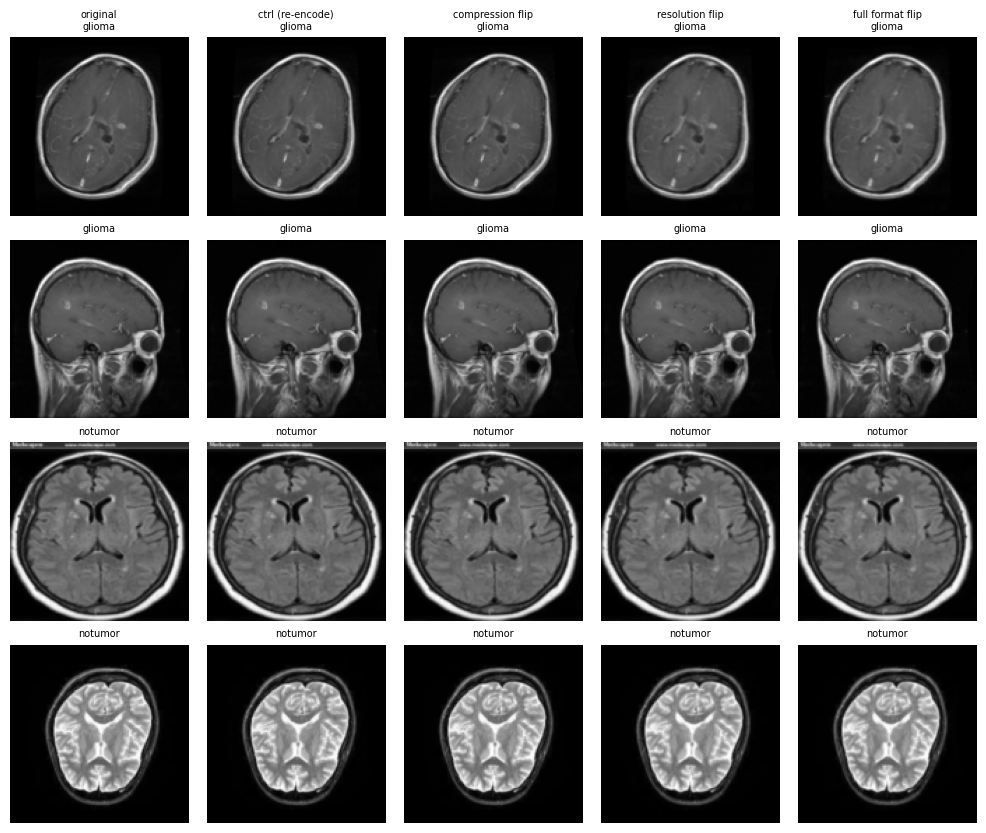

In [5]:
def check_qt(g, qt, size):                      # the re-rendered JPEG must carry the donor's table exactly
    h = g.resize(size, Image.BILINEAR) if size != g.size else g; b = io.BytesIO(); h.save(b, "JPEG", qtables=[list(qt)]); b.seek(0)
    return list(Image.open(b).quantization[0]) == list(qt)
chk = [check_qt(Image.open(df.path[i]).convert("L"), qts[d], (int(ws[d]), int(hs[d]))) for i, d in zip(valid[:5], valid[-5:])]; print("quantisation table copied exactly:", all(chk))
ex = [np.where((y != NOTU) & (df.fg.values == TSRC))[0][0], np.where((y != NOTU) & (df.fg.values == TSRC))[0][5], np.where(y == NOTU)[0][0], np.where(y == NOTU)[0][7]]
fig, ax = plt.subplots(len(ex), 5, figsize=(10, 2.1*len(ex)))
for r, i in enumerate(ex):
    for c, (im, t) in enumerate(zip([Xr[i], *Fv[i]], ["original", "ctrl (re-encode)", "compression flip", "resolution flip", "full format flip"])):
        ax[r, c].imshow(im, cmap="gray"); ax[r, c].axis("off"); ax[r, c].set_title(f"{t}\n{classes[y[i]]}" if r == 0 else classes[y[i]], fontsize=7)
plt.tight_layout(); plt.savefig(f"{OUT}/fig_format_flip_examples.png", dpi=140); plt.show()

## 4. Models and the five training methods
- `erm`: plain training on clean images.
- `fmix`: **FormatMix**, every training image re-rendered in a random donor format (class-independent).
- `fmix_ccr`: **FormatMix + consistency**, two different re-renderings of the same scan must give the same prediction (symmetric KL).
- `dro_fg`: GroupDRO with forensic groups (class x format).
- `poe_fmt`: product-of-experts debiasing; a format-only expert (cross-fitted, so it is not overconfident on its own training data) absorbs the shortcut.
All methods share the same base augmentation, optimiser and epochs. Epoch selection on validation uses 0.5 x per-group accuracy + 0.5 x accuracy under the full format flip (identical rule for every method).

In [6]:
def to_gpu(a):
    out = torch.empty(a.shape, dtype=torch.float16, device=dev)
    for i in range(0, len(a), 500): out[i:i+500] = torch.as_tensor((a[i:i+500].astype(np.float32)/255 - .45)/.225).half().to(dev)
    return out
T0, TV, TF = to_gpu(Xr), to_gpu(V), to_gpu(Fv)
yt_all, ct_all = torch.as_tensor(y).to(dev), torch.as_tensor(cid).to(dev)
def make_backbone(name):
    m = torchvision.models.get_model(name, weights=WEIGHTS[name])
    if name.startswith("resnet"): return nn.Sequential(*list(m.children())[:-2]), m.fc.in_features
    if name.startswith("densenet"): return nn.Sequential(m.features, nn.ReLU()), m.classifier.in_features
    if name.startswith(("efficientnet", "convnext")): return m.features, m.classifier[-1].in_features
    if name.startswith("regnet"): return nn.Sequential(m.stem, m.trunk_output), m.fc.in_features
    raise ValueError(name)
class Net(nn.Module):
    def __init__(s, bb):
        super().__init__(); s.f, d = make_backbone(bb); s.c = nn.Linear(d, K)
    def fmap(s, x): return s.f(x.float().unsqueeze(1).expand(-1, 3, -1, -1))
    def forward(s, x): return s.c(s.fmap(x).mean((2, 3)))
def aug(x):
    if np.random.rand() < .5: x = x.flip(-1)
    return x*(1 + .3*(torch.rand(len(x), 1, 1, device=x.device) - .5))
@torch.no_grad()
def predx(m, x):
    m.eval(); out = []
    for i in range(0, len(x), 256):
        with torch.autocast("cuda", dtype=torch.float16, enabled=(dev == "cuda")): out.append(F.softmax(m(x[i:i+256]).float(), 1).cpu())
    return torch.cat(out).numpy()
probs = lambda m, X, idx: predx(m, X[torch.as_tensor(idx).to(dev)])
def gscore(pred, idx):
    c = pred == y[idx]; a = np.bincount(cid[idx], weights=c, minlength=NC); n = np.bincount(cid[idx], minlength=NC); ok = n >= 3
    return (a[ok]/n[ok]).mean()
def vscore(m, va):
    pf = predx(m, TF[torch.as_tensor(va).to(dev), 3]).argmax(1)
    return .5*gscore(probs(m, T0, va).argmax(1), va) + .5*(pf == y[va]).mean()
def bias_logp(tr, seed):                         # cross-fitted format-only expert: out-of-fold log-probs for every training image
    lb = np.zeros((N, K), np.float32)
    for a, b in StratifiedGroupKFold(4, shuffle=True, random_state=seed).split(tr, y[tr], df.grp.values[tr]):
        g = HistGradientBoostingClassifier(max_iter=100, random_state=0).fit(FFM[tr[a]], y[tr[a]])
        p = np.full((len(b), K), 1e-3); p[:, g.classes_] = g.predict_proba(FFM[tr[b]]); lb[tr[b]] = np.log(np.clip(p, 1e-3, 1))
    return torch.as_tensor(lb).to(dev)

def fit(bb, method, tr, va, seed, LB=None):
    torch.manual_seed(seed); np.random.seed(seed); m = Net(bb).to(dev)
    opt = torch.optim.AdamW(m.parameters(), lr=LR, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=LR, total_steps=EPOCHS*int(np.ceil(len(tr)/BATCH)))
    scaler = torch.cuda.amp.GradScaler(enabled=(dev == "cuda")); q = torch.ones(NC, device=dev)/NC; best = -1
    for ep in range(EPOCHS):
        m.train(); perm = np.random.permutation(tr)
        for b in range(0, len(perm), BATCH):
            ix = torch.as_tensor(perm[b:b+BATCH]).to(dev); B = len(ix)
            if B < 4: sched.step(); continue
            if method in ("fmix", "fmix_ccr"):
                k1 = torch.randint(0, K_VAR, (B,), device=dev); x = TV[ix, k1]
                if method == "fmix_ccr": x = torch.cat([x, TV[ix, (k1 + torch.randint(1, K_VAR, (B,), device=dev)) % K_VAR]])
            else: x = T0[ix]
            with torch.autocast("cuda", dtype=torch.float16, enabled=(dev == "cuda")): lo = m(aug(x))
            lo = lo.float(); yy = yt_all[ix]
            if method == "fmix_ccr":
                l1, l2 = lo[:B], lo[B:]; p1, p2 = F.log_softmax(l1, 1), F.log_softmax(l2, 1)
                l = .5*(F.cross_entropy(l1, yy, reduction="none") + F.cross_entropy(l2, yy, reduction="none")) \
                    + CCR_LAMBDA*.5*((p1.exp()*(p1 - p2)).sum(1) + (p2.exp()*(p2 - p1)).sum(1)); loss = l.mean()
            elif method == "poe_fmt": loss = F.cross_entropy(lo + POE_ALPHA*LB[ix], yy)
            elif method == "dro_fg":
                l = F.cross_entropy(lo, yy, reduction="none"); g = ct_all[ix]; gc = torch.bincount(g, minlength=NC).float()
                gl = torch.zeros(NC, device=dev).scatter_add(0, g, l)/gc.clamp(min=1)
                q = q*torch.exp(DRO_ETA*gl.detach()*(gc > 0)); q = q/q.sum(); loss = (q*gl).sum()
            else: loss = F.cross_entropy(lo, yy)
            opt.zero_grad(); scaler.scale(loss).backward(); scaler.step(opt); scaler.update(); sched.step()
        a = vscore(m, va)
        if a >= best: best, st = a, {k_: v_.clone() for k_, v_ in m.state_dict().items()}
    m.load_state_dict(st); return m, best
@torch.no_grad()
def feats(m, X, idx):
    m.eval(); ix = torch.as_tensor(idx).to(dev)
    return torch.cat([m.fmap(X[ix[i:i+256]]).mean((2, 3)).float().cpu() for i in range(0, len(ix), 256)]).numpy()

## 5. Experiments (resumable). Primary architecture: 3 seeds. Secondary architecture: 1 seed (generality check).

In [7]:
METHODS = ["erm", "fmix", "fmix_ccr", "dro_fg", "poe_fmt"]; BASE, PROP = "erm", "fmix_ccr"
def run_grid(bb, seeds):
    n_tot = len(seeds)*(NFOLD + 1)*len(METHODS); pbar = tqdm(total=n_tot, desc=bb)
    for seed in seeds:
        for sp, tr, va, te in make_splits(seed):
            LB = bias_logp(tr, seed) if "poe_fmt" in METHODS else None
            for mt in METHODS:
                f = f"{RUNS}/{bb}__{mt}__s{seed}__{sp}.npz"
                if os.path.exists(f): pbar.update(1); continue
                m, vs = fit(bb, mt, tr, va, seed, LB); p = probs(m, T0, te); ti = torch.as_tensor(te).to(dev)
                pf = np.stack([predx(m, TF[ti, v]).argmax(1) for v in range(4)], 1); probe = np.nan
                if sp == "f0" and seed == seeds[0]:
                    sub = np.random.RandomState(0).choice(tr, min(2500, len(tr)), replace=False)
                    lr = LogisticRegression(max_iter=300, class_weight="balanced").fit(feats(m, T0, sub), is_nsrc[sub])
                    probe = balanced_accuracy_score(is_nsrc[te], lr.predict(feats(m, T0, te))); torch.save(m.state_dict(), f"{MODELS}/{bb}__{mt}.pt")
                np.savez(f, te=te, pred=p.argmax(1), conf=p.max(1), prob=p.astype(np.float16), pf=pf, probe=probe, vscore=vs)
                del m; torch.cuda.empty_cache() if dev == "cuda" else None; pbar.update(1)
run_grid(ARCH1, SEEDS1)
if ARCH2: run_grid(ARCH2, SEEDS2)

convnext_tiny:   0%|          | 0/90 [00:00<?, ?it/s]

resnet50:   0%|          | 0/30 [00:00<?, ?it/s]

## 6. Results: clean accuracy, format-flip robustness, format-controlled accuracy, worst group

In [8]:
ARCHS_RUN = [a for a in (ARCH1, ARCH2) if a]
def load_runs():
    raw = {}
    for f in sorted(glob.glob(f"{RUNS}/*.npz")):
        bb, mt, s, sp = os.path.basename(f)[:-4].split("__"); z = np.load(f); raw.setdefault((bb, mt, int(s[1:])), {})[sp] = {a: z[a] for a in z.files}
    R, OFF = {}, {}
    for key, d in raw.items():
        if all(f"f{k}" in d for k in range(NFOLD)):
            e = dict(runs=[d[f"f{k}"] for k in range(NFOLD)], pred=np.zeros(N, np.int64), conf=np.zeros(N, np.float32), pf=np.zeros((N, 4), np.int64))
            for r in e["runs"]: e["pred"][r["te"]] = r["pred"]; e["conf"][r["te"]] = r["conf"]; e["pf"][r["te"]] = r["pf"]
            R[key] = e
        if "off" in d: OFF[key] = d["off"]
    return R, OFF
R, OFF = load_runs(); print(len(R), "complete CV combinations |", len(OFF), "official-split runs")
def ece(conf, cor, nb=15):
    e = 0; bins = np.linspace(0, 1, nb+1)
    for lo, hi in zip(bins[:-1], bins[1:]):
        s = (conf > lo) & (conf <= hi); e += s.mean()*abs(cor[s].mean() - conf[s].mean()) if s.any() else 0
    return e
def metrics_on(idx, pred, pf, conf=None, min_cell=MIN_CELL):
    yy = y[idx]; c = pred == yy; tum = yy != NOTU; nt = ~tum; r = dict(acc=c.mean(), macro_f1=f1_score(yy, pred, average="macro"))
    if conf is not None: r["ece"] = ece(conf, c)
    for v, nm in enumerate(["ctrl", "comp", "res", "full"]): r[f"acc_{nm}"] = (pf[:, v] == yy).mean()
    r["FN_ctrl"], r["FN_full"] = (pf[tum, 0] == NOTU).mean(), (pf[tum, 3] == NOTU).mean()
    r["FP_ctrl"], r["FP_full"] = (pf[nt, 0] != NOTU).mean(), (pf[nt, 3] != NOTU).mean()
    r["FSI"] = (pf[:, 3] != pred).mean() - (pf[:, 0] != pred).mean()                   # Format Sensitivity Index (net of re-encoding)
    a = np.bincount(cid[idx], weights=c, minlength=NC); n = np.bincount(cid[idx], minlength=NC); ok = n >= min_cell
    r["worst_cell"], r["avg_cell"] = (a[ok]/n[ok]).min(), (a[ok]/n[ok]).mean()
    for nm, msk in (("fc_strict", fc_strict), ("fc_broad", fc_broad)):
        mm = msk[idx]; r[f"acc_{nm}"] = c[mm].mean() if mm.any() else np.nan
    return r
per = pd.DataFrame([dict(arch=bb, method=mt, seed=s, **metrics_on(np.arange(N), e["pred"], e["pf"], e["conf"])) for (bb, mt, s), e in R.items()])
per.to_csv(f"{OUT}/per_seed_cv.csv", index=False); cols = ["acc","macro_f1","ece","acc_full","FN_full","FP_full","FSI","acc_fc_strict","worst_cell"]
g = per.groupby(["arch","method"]); mu, sd = g[cols].mean(), g[cols].std().fillna(0)
tab = (mu.round(4).astype(str) + " +/- " + sd.round(4).astype(str)).reindex(pd.MultiIndex.from_product([ARCHS_RUN, METHODS], names=["arch","method"])).dropna(how="all")
print("CROSS-VALIDATION (pooled out-of-fold, duplicate-safe)"); print(tab.to_string()); tab.to_csv(f"{OUT}/table_cv.csv"); mu.to_csv(f"{OUT}/table_cv_mean.csv")
print("\nFactor attribution (accuracy under each controlled flip; ctrl = re-encode only):")
fa = g[["acc", "acc_ctrl", "acc_comp", "acc_res", "acc_full"]].mean().round(4).reindex(pd.MultiIndex.from_product([ARCHS_RUN, METHODS], names=["arch","method"])).dropna(); print(fa.to_string()); fa.to_csv(f"{OUT}/table_factor_attribution.csv")
rows = []
for (bb, mt, s), r in OFF.items():
    te = r["te"]; rows.append(dict(arch=bb, method=mt, seed=s, **metrics_on(te, r["pred"], r["pf"], r["conf"], min_cell=10)))
off = pd.DataFrame(rows)
if len(off):
    og = off.groupby(["arch","method"])[cols].mean().round(4).reindex(pd.MultiIndex.from_product([ARCHS_RUN, METHODS], names=["arch","method"])).dropna()
    print("\nOFFICIAL SPLIT (train on Training folder, test on Testing folder)"); print(og.to_string()); og.to_csv(f"{OUT}/table_official_split.csv")

20 complete CV combinations | 20 official-split runs
CROSS-VALIDATION (pooled out-of-fold, duplicate-safe)
                                      acc           macro_f1                ece           acc_full            FN_full            FP_full                FSI      acc_fc_strict         worst_cell
arch          method                                                                                                                                                                             
convnext_tiny erm       0.9747 +/- 0.0021  0.9743 +/- 0.0021  0.0154 +/- 0.0023  0.9739 +/- 0.0023  0.0063 +/- 0.0017  0.0176 +/- 0.0012  0.0036 +/- 0.0011   0.887 +/- 0.0161  0.5833 +/- 0.0725
              fmix      0.9748 +/- 0.0028  0.9745 +/- 0.0028  0.0145 +/- 0.0018  0.9744 +/- 0.0018  0.0061 +/- 0.0006  0.0198 +/- 0.0047  0.0029 +/- 0.0007  0.8733 +/- 0.0088  0.4912 +/- 0.0274
              fmix_ccr   0.975 +/- 0.0049   0.9747 +/- 0.005  0.0137 +/- 0.0011  0.9745 +/- 0.0049  0.0059 +/- 0.0014

## 7. Statistics: duplicate-aware bootstrap CIs, paired differences vs ERM, Wilcoxon

95% duplicate-aware bootstrap CIs (seed-averaged, pooled OOF):
            arch    method            clean_acc        fc_strict_acc        full_flip_acc              FN_full              FP_full           worst_cell
0  convnext_tiny       erm  0.975 [0.971,0.979]  0.887 [0.859,0.912]  0.974 [0.970,0.978]  0.006 [0.004,0.010]  0.018 [0.011,0.025]  0.581 [0.473,0.688]
1  convnext_tiny      fmix  0.975 [0.971,0.979]  0.873 [0.845,0.899]  0.974 [0.970,0.978]  0.006 [0.003,0.010]  0.020 [0.013,0.028]  0.492 [0.395,0.594]
2  convnext_tiny  fmix_ccr  0.975 [0.971,0.979]  0.884 [0.855,0.909]  0.975 [0.970,0.979]  0.006 [0.003,0.009]  0.020 [0.013,0.029]  0.560 [0.464,0.662]
3  convnext_tiny    dro_fg  0.963 [0.958,0.968]  0.873 [0.845,0.899]  0.962 [0.957,0.966]  0.007 [0.004,0.011]  0.028 [0.019,0.039]  0.657 [0.564,0.745]
4  convnext_tiny   poe_fmt  0.962 [0.957,0.968]  0.867 [0.841,0.891]  0.961 [0.956,0.966]  0.013 [0.011,0.016]  0.054 [0.039,0.069]  0.717 [0.627,0.802]
5       resnet50   

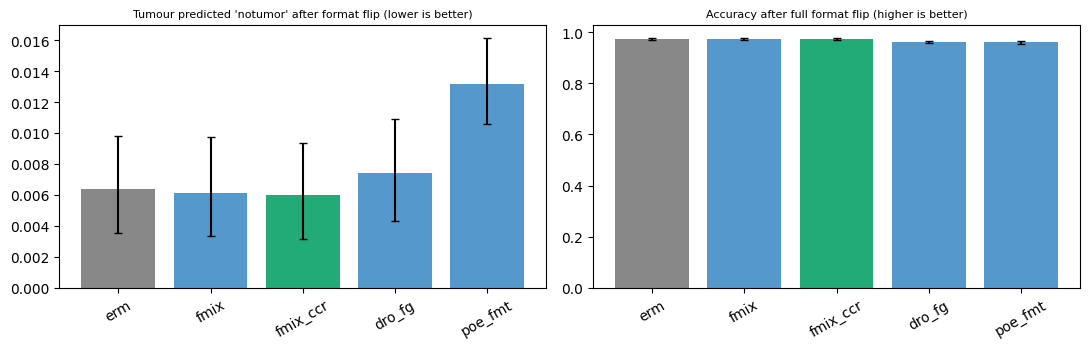

In [9]:
ug, gi = np.unique(df.grp.values, return_inverse=True); NG = len(ug); B = 1000; IX = np.random.RandomState(0).randint(0, NG, (B, NG))
def boot_ratio(v, mask):
    num = np.bincount(gi, weights=v*mask, minlength=NG); den = np.bincount(gi, weights=mask, minlength=NG)
    return num[IX].sum(1)/np.maximum(den[IX].sum(1), 1e-9)
den_m = np.zeros((NG, NC)); np.add.at(den_m, (gi, cid), 1.0)
def boot_worst(v):
    num = np.zeros((NG, NC)); np.add.at(num, (gi, cid), v); out = np.zeros(B)
    for b in range(B):
        n_, d_ = num[IX[b]].sum(0), den_m[IX[b]].sum(0); ok = okcell & (d_ > 0); out[b] = (n_[ok]/d_[ok]).min()
    return out
f_cl = lambda e: (e["pred"] == y).astype(float); f_full = lambda e: (e["pf"][:, 3] == y).astype(float)
f_fn = lambda e: (e["pf"][:, 3] == NOTU).astype(float); f_fp = lambda e: (e["pf"][:, 3] != NOTU).astype(float)
ONE = np.ones(N); SPEC = {"clean_acc": (f_cl, ONE), "fc_strict_acc": (f_cl, fc_strict.astype(float)), "full_flip_acc": (f_full, ONE),
                           "FN_full": (f_fn, (y != NOTU).astype(float)), "FP_full": (f_fp, (y == NOTU).astype(float))}
bres = {}; seeds_of = {ARCH1: SEEDS1, ARCH2: SEEDS2}
for bb in ARCHS_RUN:
    for mt in METHODS:
        ss = [s for s in seeds_of[bb] if (bb, mt, s) in R]
        if not ss: continue
        d = {nm: boot_ratio(np.mean([fn(R[(bb, mt, s)]) for s in ss], 0), mk) for nm, (fn, mk) in SPEC.items()}
        d["worst_cell"] = boot_worst(np.mean([f_cl(R[(bb, mt, s)]) for s in ss], 0)); bres[(bb, mt)] = d
ci = lambda a: f"{a.mean():.3f} [{np.percentile(a,2.5):.3f},{np.percentile(a,97.5):.3f}]"
rows_ci, rows_df = [], []
def run_val(r, name):
    te = r["te"]; yy = y[te]
    if name == "full_flip_acc": return (r["pf"][:, 3] == yy).mean()
    if name == "FN_full": t = yy != NOTU; return (r["pf"][t, 3] == NOTU).mean()
    if name == "fc_strict_acc": m_ = fc_strict[te]; return (r["pred"][m_] == yy[m_]).mean() if m_.any() else np.nan
for bb in ARCHS_RUN:
    for mt in METHODS:
        if (bb, mt) not in bres: continue
        rows_ci.append(dict(arch=bb, method=mt, **{k: ci(v) for k, v in bres[(bb, mt)].items()}))
        if mt != BASE and (bb, BASE) in bres:
            r = dict(arch=bb, method=mt)
            for k in ["full_flip_acc", "FN_full", "FP_full", "fc_strict_acc", "worst_cell", "clean_acc"]:
                dd = bres[(bb, mt)][k] - bres[(bb, BASE)][k]; r[f"d_{k}"] = f"{dd.mean():+.3f} [{np.percentile(dd,2.5):+.3f},{np.percentile(dd,97.5):+.3f}]"; r[f"P(better)_{k}"] = round(float((dd < 0).mean() if k.startswith("FN") or k.startswith("FP") else (dd > 0).mean()), 3)
            for k in ["full_flip_acc", "FN_full", "fc_strict_acc"]:
                a_, b_ = [], []
                for s in seeds_of[bb]:
                    if (bb, mt, s) in R and (bb, BASE, s) in R:
                        for ra, rb in zip(R[(bb, mt, s)]["runs"], R[(bb, BASE, s)]["runs"]): a_.append(run_val(ra, k)); b_.append(run_val(rb, k))
                a_, b_ = np.array(a_, float), np.array(b_, float); ok = ~np.isnan(a_) & ~np.isnan(b_)
                try: r[f"wilcoxon_p_{k}"] = round(float(wilcoxon(a_[ok] - b_[ok]).pvalue), 4)
                except Exception: r[f"wilcoxon_p_{k}"] = np.nan
            rows_df.append(r)
ci_df, diff_df = pd.DataFrame(rows_ci), pd.DataFrame(rows_df)
print("95% duplicate-aware bootstrap CIs (seed-averaged, pooled OOF):"); print(ci_df.to_string()); print("\nDifferences vs ERM:"); print(diff_df.T.to_string())
ci_df.to_csv(f"{OUT}/table_ci.csv", index=False); diff_df.to_csv(f"{OUT}/table_diff_vs_erm.csv", index=False)
fig, axs = plt.subplots(1, 2, figsize=(11, 3.6)); bb = ARCH1; ms = [m for m in METHODS if (bb, m) in bres]; col = ["#888" if m == BASE else "#2a7" if m == PROP else "#59c" for m in ms]
for a, k, t in zip(axs, ["FN_full", "full_flip_acc"], ["Tumour predicted 'notumor' after format flip (lower is better)", "Accuracy after full format flip (higher is better)"]):
    mu_ = [bres[(bb, m)][k].mean() for m in ms]; a.bar(ms, mu_, yerr=[[mu_[i] - np.percentile(bres[(bb, m)][k], 2.5) for i, m in enumerate(ms)], [np.percentile(bres[(bb, m)][k], 97.5) - mu_[i] for i, m in enumerate(ms)]], capsize=3, color=col)
    a.set_title(t, fontsize=8); a.tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.savefig(f"{OUT}/fig_format_flip_results.png", dpi=150); plt.show()

## 8. Mechanism: is the format still readable from the embeddings? Where does attention go?

Balanced accuracy of reading 'no-tumour source format' from embeddings (0.5 = hidden, 1 = fully encoded):
                        format_decodable_from_embedding
arch          method                                   
convnext_tiny dro_fg                              0.971
              erm                                 0.975
              fmix                                0.969
              fmix_ccr                            0.964
              poe_fmt                             0.964
resnet50      dro_fg                              0.953
              erm                                 0.953
              fmix                                0.935
              fmix_ccr                            0.953
              poe_fmt                             0.936


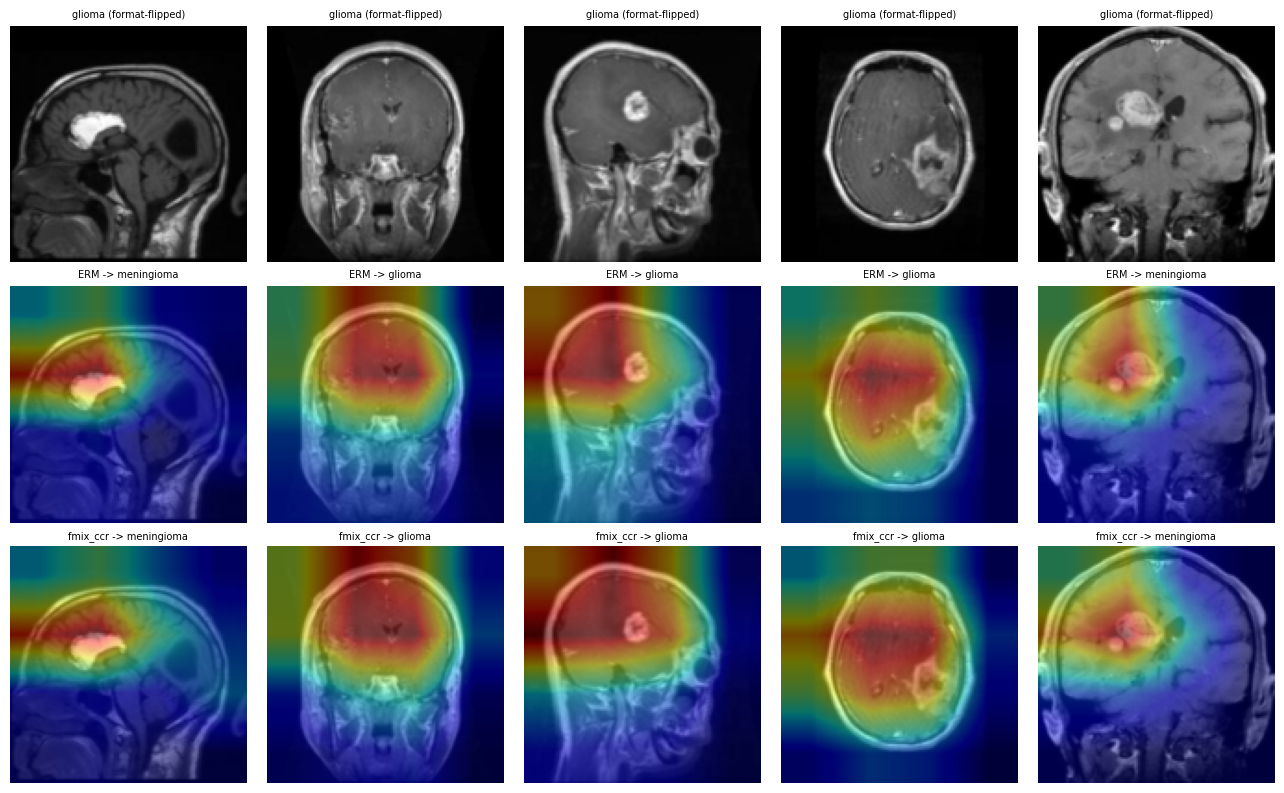

In [10]:
rows = [dict(arch=bb, method=mt, format_decodable_from_embedding=float(np.nanmax([r["probe"] for r in e["runs"]]))) for (bb, mt, s), e in R.items() if s == (SEEDS1 if bb == ARCH1 else SEEDS2)[0]]
pr = pd.DataFrame(rows).set_index(["arch","method"]).round(3); print("Balanced accuracy of reading 'no-tumour source format' from embeddings (0.5 = hidden, 1 = fully encoded):"); print(pr.to_string()); pr.to_csv(f"{OUT}/table_probe.csv")
def gradcam(m, X, i):
    m.eval(); x = X[i:i+1]
    with torch.enable_grad():
        f = m.fmap(x); lo = m.c(f.mean((2, 3))); c = int(lo.argmax(1)); gr = torch.autograd.grad(lo[0, c], f)[0]
        cam = F.relu((gr.mean((2, 3), keepdim=True)*f).sum(1, keepdim=True)).detach()
    cam = F.interpolate(cam, size=(IMG, IMG), mode="bilinear")[0, 0]; return (cam/(cam.max() + 1e-8)).cpu().numpy(), c
pa, pb_ = f"{MODELS}/{ARCH1}__{BASE}.pt", f"{MODELS}/{ARCH1}__{PROP}.pt"
if os.path.exists(pa) and os.path.exists(pb_) and (ARCH1, BASE, SEEDS1[0]) in R:
    ma, mb = Net(ARCH1).to(dev), Net(ARCH1).to(dev); ma.load_state_dict(torch.load(pa)); mb.load_state_dict(torch.load(pb_))
    te = R[(ARCH1, BASE, SEEDS1[0])]["runs"][0]["te"]; te = te[y[te] != NOTU]; bad = te[(probs(ma, TF[:, 3], te).argmax(1) == NOTU) & (probs(mb, TF[:, 3], te).argmax(1) != NOTU)]
    pick = (bad if len(bad) else te)[:5]
    fig, axs = plt.subplots(3, len(pick), figsize=(2.6*len(pick), 8), squeeze=False)
    for j, i in enumerate(pick):
        ca, pa_ = gradcam(ma, TF[:, 3], i); cb_, pb2 = gradcam(mb, TF[:, 3], i)
        for r_, (im, t) in enumerate([(None, f"{classes[y[i]]} (format-flipped)"), (ca, f"ERM -> {classes[pa_]}"), (cb_, f"{PROP} -> {classes[pb2]}")]):
            axs[r_, j].imshow(Fv[i, 3], cmap="gray"); axs[r_, j].axis("off"); axs[r_, j].set_title(t, fontsize=7)
            if im is not None: axs[r_, j].imshow(im, cmap="jet", alpha=.45)
    plt.tight_layout(); plt.savefig(f"{OUT}/fig_gradcam_flipped.png", dpi=150); plt.show()

## 9. Optional external validation (set `EXT_ROOT` to a folder with one sub-folder per class)

In [11]:
if EXT_ROOT and os.path.isdir(EXT_ROOT):
    def cls_of(n):
        n = n.lower()
        for k in ("glioma", "meningioma", "pituitary"):
            if k in n and k in classes: return classes.index(k)
        return classes.index("notumor") if any(t in n for t in ("notumor", "no_tumor", "no tumor", "normal", "healthy")) or n in ("no", "non") else None
    items = [(f, cls_of(os.path.basename(d.rstrip("/")))) for d in glob.glob(f"{EXT_ROOT}/**/", recursive=True) for f in glob.glob(d + "*") if f.lower().endswith((".jpg", ".jpeg", ".png"))]
    items = [(f, c) for f, c in items if c is not None]; ey = np.array([c for _, c in items]); print(len(items), "external images")
    ET = to_gpu(np.stack([std_from(Image.open(f)) for f, _ in tqdm(items)])); rows = []
    for bb in ARCHS_RUN:
        for mt in METHODS:
            pth = f"{MODELS}/{bb}__{mt}.pt"
            if os.path.exists(pth):
                m = Net(bb).to(dev); m.load_state_dict(torch.load(pth)); pr_ = predx(m, ET).argmax(1)
                rows.append(dict(arch=bb, method=mt, ext_acc=(pr_ == ey).mean(), ext_macro_f1=f1_score(ey, pr_, average="macro", labels=np.unique(ey))))
    ext = pd.DataFrame(rows).round(4); print(ext.to_string()); ext.to_csv(f"{OUT}/table_external.csv", index=False)
else: print("EXT_ROOT not set: skipping.")

EXT_ROOT not set: skipping.


In [12]:
with open(f"{OUT}/tables.tex", "w") as fh:
    for nm_, t in [("cv", mu.round(3)), ("diff", diff_df), ("probe", pr)]: fh.write(f"% {nm_}\n" + t.to_latex() + "\n")
print(f"Headline audit numbers: format-only classifier acc={acc_fmt:.3f} (SRI {chance(acc_fmt):.3f}); notumor-source format purity={ctab.loc[NSRC,'notumor']/ctab.loc[NSRC,'n']:.3f}")
print(sorted(os.listdir(OUT)))

Headline audit numbers: format-only classifier acc=0.582 (SRI 0.442); notumor-source format purity=1.000
['cache_v5_N6997_K5.npz', 'config.json', 'fig_format_flip_examples.png', 'fig_format_flip_results.png', 'fig_gradcam_flipped.png', 'models', 'per_seed_cv.csv', 'runs', 'table_ci.csv', 'table_cv.csv', 'table_cv_mean.csv', 'table_diff_vs_erm.csv', 'table_factor_attribution.csv', 'table_format_groups.csv', 'table_official_split.csv', 'table_probe.csv', 'tables.tex']


## 10. Reading the results and writing the paper
- **If `erm` collapses under the format flip and `fmix`/`fmix_ccr` do not:** headline = "benchmark accuracy overstates reliability; do(format) training restores it".
- **If `ctrl` already changes predictions:** re-encoding itself is a nuisance; report net effects (FSI) as built here.
- **Factor table** tells which factor (compression, resolution) drives the shortcut. This is a finding on its own.
- **Honest reporting:** if a baseline (`dro_fg`, `poe_fmt`) wins on some metric, say so. Mention the 203 pre-augmented files and how results change with `DROP_AUG=0`.
- **Before submission:** literature check for shortcut learning, dataset bias in medical imaging and counterfactual invariance; external validation (section 9); radiologist review of failure cases; release code and the format-group labels.